In [3]:
# ============================================================
# ✅ IMPORTS
# ============================================================
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [5]:
# ============================================================
# ✅ PATH SETUP
# ============================================================
TRAIN_DIR = "/kaggle/input/brisc2025/brisc2025/classification_task/train"
WORK_DIR = "/kaggle/working/results"
os.makedirs(WORK_DIR, exist_ok=True)

if not os.path.exists(TRAIN_DIR):
    raise FileNotFoundError(f"Train directory not found: {TRAIN_DIR}")

# ============================================================
# ✅ DATA GENERATORS
# ============================================================
batch_size = 16
target_size = (224, 224)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=12,
    width_shift_range=0.12,
    height_shift_range=0.12,
    shear_range=0.15,
    zoom_range=0.2,
    brightness_range=[0.9, 1.1],
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="sparse",
    subset="training",
    shuffle=True,
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="sparse",
    subset="validation",
    shuffle=False,
    seed=42
)

num_classes = len(train_generator.class_indices)
class_names = list(train_generator.class_indices.keys())

print("Detected classes:", train_generator.class_indices)

Found 4002 images belonging to 4 classes.
Found 998 images belonging to 4 classes.
Detected classes: {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}


In [6]:
# ============================================================
# ✅ RESNET50 + GAP
# ============================================================
base_model = ResNet101(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(256, activation="relu",
          kernel_regularizer=regularizers.l2(1e-3))(x)
x = Dropout(0.5)(x)

outputs = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

# ============================================================
# ✅ COMPILE
# ============================================================
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

I0000 00:00:1770617760.917039      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770617760.923042      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 43,191,940 (164.76 MB)

 Trainable params: 43,082,500 (164.35 MB)

 Non-trainable params: 109,440 (427.50 KB)

In [7]:
# ============================================================
# ✅ CALLBACKS
# ============================================================
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

# ============================================================
# ✅ TRAINING
# ============================================================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1770617832.398323     155 service.cc:152] XLA service 0x796574001730 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770617832.398361     155 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1770617832.398365     155 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1770617843.075121     155 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1770617872.466043     155 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


251/251 ━━━━━━━━━━━━━━━━━━━━ 238s 565ms/step - accuracy: 0.7384 - loss: 1.2373 - val_accuracy: 0.2495 - val_loss: 4.6494 - learning_rate: 1.0000e-04
Epoch 2/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 100s 399ms/step - accuracy: 0.9158 - loss: 0.6911 - val_accuracy: 0.2615 - val_loss: 6.9404 - learning_rate: 1.0000e-04
Epoch 3/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 100s 399ms/step - accuracy: 0.9208 - loss: 0.6596 - val_accuracy: 0.5190 - val_loss: 4.0085 - learning_rate: 1.0000e-04
Epoch 4/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 100s 396ms/step - accuracy: 0.9449 - loss: 0.6020 - val_accuracy: 0.5110 - val_loss: 3.1616 - learning_rate: 1.0000e-04
Epoch 5/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 100s 397ms/step - accuracy: 0.9594 - loss: 0.5583 - val_accuracy: 0.8086 - val_loss: 1.1478 - learning_rate: 1.0000e-04
Epoch 6/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 100s 397ms/step - accuracy: 0.9639 - loss: 0.5312 - val_accuracy: 0.5782 - val_loss: 4.3207 - learning_rate: 1.0000e-04
Epoch 7/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 100s 

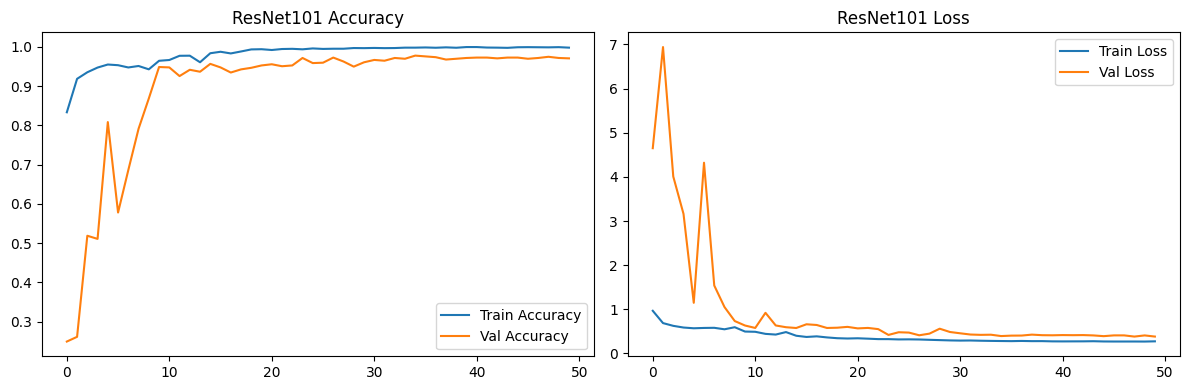

In [10]:
# ============================================================
# ✅ TRAINING CURVES
# ============================================================
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("ResNet101 Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("ResNet101 Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# ✅ FINAL EVALUATION
# ============================================================
val_loss, val_acc = model.evaluate(val_generator, verbose=0)
print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc*100:.2f}%")

# ============================================================
# ✅ METRICS & CONFUSION MATRIX
# ============================================================
val_generator.reset()
pred_probs = model.predict(val_generator, verbose=0)
y_pred = np.argmax(pred_probs, axis=1)
y_true = val_generator.classes

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="macro")
rec  = recall_score(y_true, y_pred, average="macro")
f1   = f1_score(y_true, y_pred, average="macro")

print(f"\n✅ Accuracy:  {acc*100:.2f}%")
print(f"✅ Precision:{prec*100:.2f}%")
print(f"✅ Recall:   {rec*100:.2f}%")
print(f"✅ F1-score: {f1*100:.2f}%")


Validation Loss: 0.4127
Validation Accuracy: 97.09%

Classification Report:

              precision    recall  f1-score   support

      glioma       1.00      0.99      0.99       229
  meningioma       0.97      0.95      0.96       265
    no_tumor       0.95      0.99      0.97       213
   pituitary       0.99      0.98      0.99       291

    accuracy                           0.98       998
   macro avg       0.98      0.98      0.98       998
weighted avg       0.98      0.98      0.98       998


✅ Accuracy:  97.70%
✅ Precision:97.63%
✅ Recall:   97.77%
✅ F1-score: 97.69%


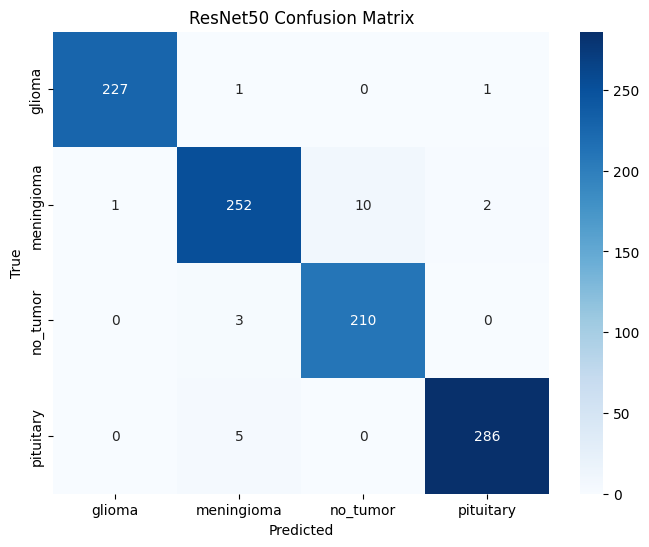

In [16]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [17]:
# ============================================================
# ✅ SAVE RESULTS
# ============================================================
pred_path = os.path.join(WORK_DIR, "predictions.csv")
np.savetxt(
    pred_path,
    np.column_stack([y_true, y_pred]),
    delimiter=",",
    header="true_label,predicted_label",
    comments="",
    fmt="%d"
)

metrics_path = os.path.join(WORK_DIR, "metrics.csv")
with open(metrics_path, "w") as f:
    f.write("metric,value\n")
    f.write(f"accuracy,{acc:.6f}\n")
    f.write(f"precision_macro,{prec:.6f}\n")
    f.write(f"recall_macro,{rec:.6f}\n")
    f.write(f"f1_macro,{f1:.6f}\n")

cm_path = os.path.join(WORK_DIR, "confusion_matrix.npy")
np.save(cm_path, cm)

# ============================================================
# ✅ ZIP RESULTS
# ============================================================
zip_path = "/kaggle/working/resnet101_results.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(pred_path, "predictions.csv")
    zipf.write(metrics_path, "metrics.csv")
    zipf.write(cm_path, "confusion_matrix.npy")

print(f"\n✅ Results ZIP saved at: {zip_path}")


✅ Results ZIP saved at: /kaggle/working/resnet101_results.zip
